In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

C:\Users\Lena\Promotion\neurolib\GUI\current\gui\data\00181
00181


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]
elif case[3] == '3':
    cntrl_vars_init = [0]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '4':
    cntrl_vars_init = [1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '5':
    cntrl_vars_init = [0,1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '6':
    cntrl_vars_init = [0]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-6) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '7':
    cntrl_vars_init = [1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-6) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
elif case[3] == '8':
    cntrl_vars_init = [0,1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-6) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    
if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 4
limit = 40
i_range = range(0, limit,i_stepsize)
i_range_0 = range(0, limit,i_stepsize)
i_range_1 = range(0, limit,i_stepsize)
data.set_parameters(aln)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.40000000000000013
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003


In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  0 , total integrated cost =  13602.2666253313
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  12 0.47500000000000014 0.4250000000000001

In [14]:
factor_iteration = 20.
aln.params.duration = dur

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    ##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if conv_init[i] == [True, True]:
    
        with open(read_file,'rb') as f:
            load_array = pickle.load(f)

        bestControl_read = load_array[0]

        bestControl_init[i] = np.zeros(( 1, 6, n_dur + n_pre + n_post -2 ))
        bestControl_init[i][:,:,n_pre-1+1000:n_pre-1+2000] = bestControl_read[i][:,:,n_pre-1:n_pre-1+1000].copy()
        weights_init = load_array[7]
        
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]   
        cost.setParams(weights_init[i][0], weights_init[i][1], weights_init[i][2])

        
        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = 0, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        continue
    
    
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 5835.454352552801
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5792.3329950222
Gradient descend method:  None
RUN  0 , total integrated cost =  5792.3329950222
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 0.0 24836.53440722506
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13504.77083476605
Gradient descend method:  None
RUN  0 , total integrated cost =  13504.77083476605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 37522.48249323874
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17320.051142549542
Gradient descend method:  None
RUN  0 , total integrated cost =  17320.051142549542
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  1

ERROR:root:Problem in initial value trasfer


interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2971.78319814443
Gradient descend method:  None
RUN  0 , total integrated cost =  2971.78319814443
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65171457577383 -56.651714827846305
-------  28 0.5000000000000002 0.5000000000000002
set cost params:  1.0 0.0 7294.105296179505
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20948.406384459275
Gradient descend method:  None
RUN  0 , total integrated cost =  20948.406384459275
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  32 0.47500000000000014 0.5250000000000002
set cost params:  1.0 0.0 4002.7010472296797
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16462.096250364582
Gradient descend method:  None
RUN  0 , total integrated cost =  16462.096250364582
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  36 0

--------- 0


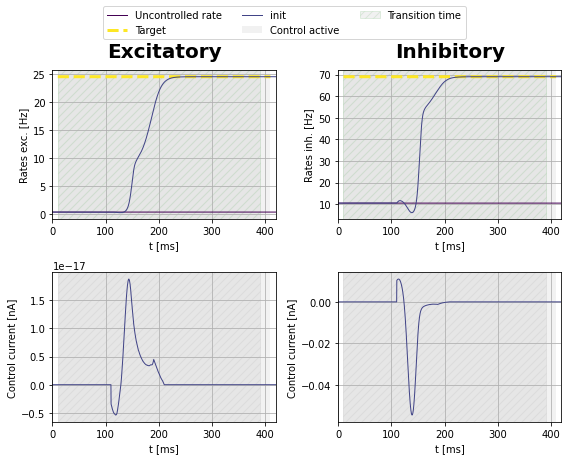

--------- 4


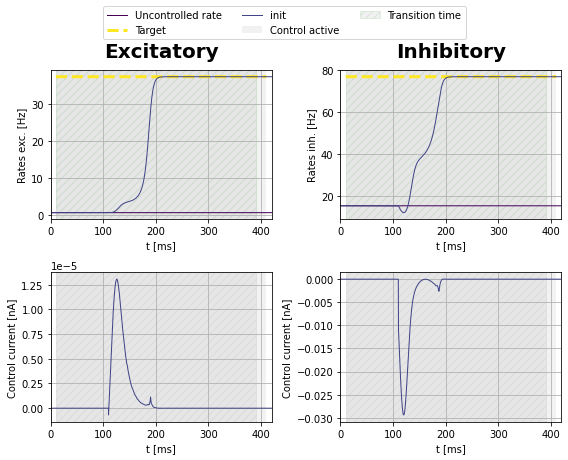

--------- 8


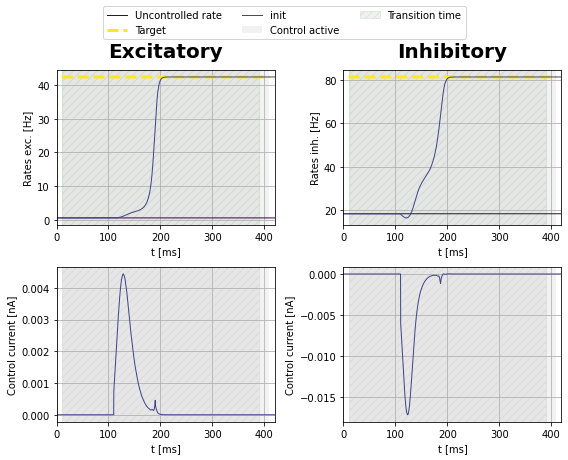

--------- 12


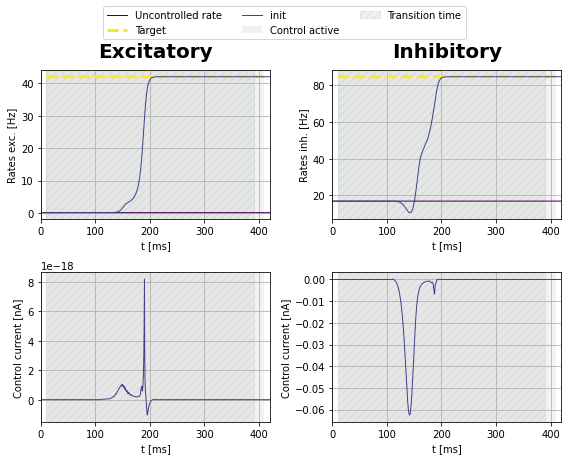

--------- 16


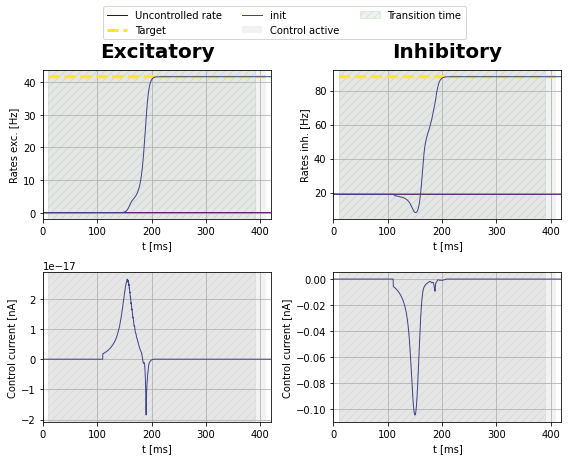

--------- 20


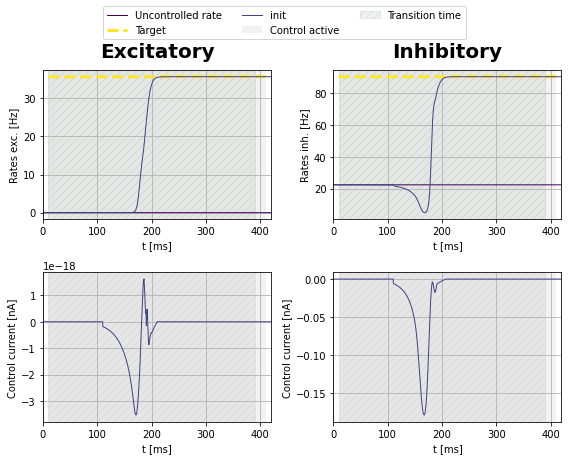

--------- 24


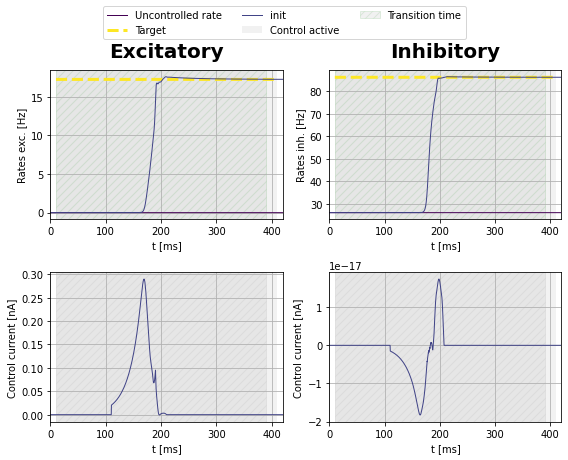

--------- 28


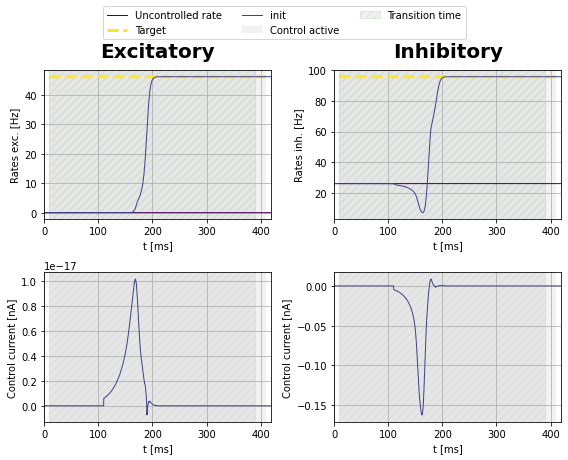

--------- 32


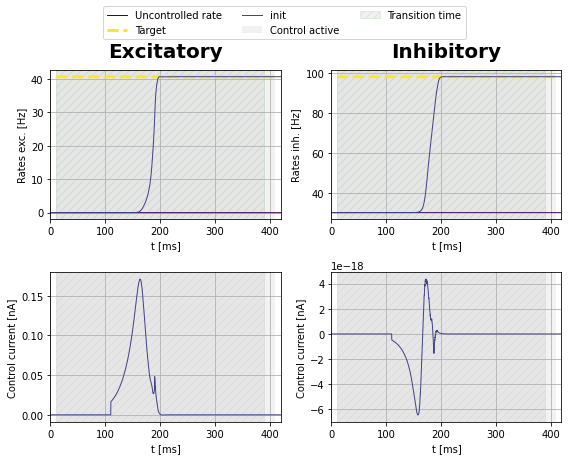

--------- 36


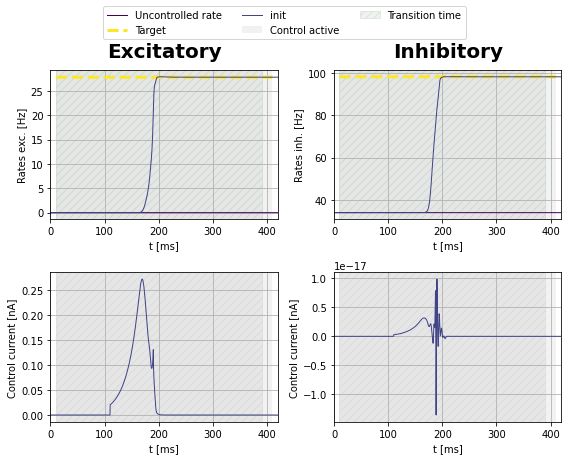

In [15]:

#plot initial guesses
for i in i_range:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [16]:
found_solution = []
no_solution = []
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])    


    if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.1 * np.abs(
        np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
        np.mean(bestState_init[i][0,1,-300:]) - target[i][0,1,-1]) < 0.1 * np.abs(
        np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amax(
        bestState_init[i][0,0,:]) < target[i][0,0,-1] + 5. and np.amax(
        bestState_init[i][0,1,:]) < target[i][0,1,-1] + 5.:
        # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
        #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
        if i not in found_solution:
            print("found solution for ", i)
            found_solution.append(i)
        if i in no_solution:
            no_solution.pop(no_solution.index(i))
        

-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  4 0.4500000000000001 0.3750000000000001
found solution for  4
-------  8 0.47500000000000014 0.40000000000000013
found solution for  8
-------  12 0.47500000000000014 0.42500000000000016
found solution for  12
-------  16 0.47500000000000014 0.4500000000000002
found solution for  16
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  24 0.4000000000000001 0.5000000000000002
found solution for  24
-------  28 0.5000000000000002 0.5000000000000002
found solution for  28
-------  32 0.47500000000000014 0.5250000000000002
found solution for  32
-------  36 0.4250000000000001 0.5500000000000003
found solution for  36


In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [18]:
factor_iteration = 6
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 6:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  6296.426187665635
set cost params:  1.0 0.0 6296.426187665635
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.469206406064
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5901.469206406064
Control only changes marginally.
RUN  1 , total integrated cost =  5901.469206406064
Improved over  1  iterations in  54.75523120000001  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.627610257693654 -56.627610362388225
converged for  0
-------  4 0.4500000000000001 0.3750000000000001
weight =  25014.838268546402
set cost params:  1.0 0.0 25014.838268546402
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13601.722879146211
Gradient descend method:  None
RUN  1 , total integrated cost =  13109.965187694923
RUN  2 , total integrated cost =  13099.42713877847
RUN  3 , total integrated cost =  13099.380687495526
RUN  4 , total integrated cost =  13099.379667395893
RUN  5 , total integrated cost =  12635.530101248061
RUN  6 , total integrated cost =  11842.965927287678
RUN  7 , total integrated cost =  11834.224410663093
RUN  8 , total integrated cost =  11833.787334831906
RUN  9 , total 

RUN  13 , total integrated cost =  16555.155671691213
RUN  14 , total integrated cost =  16555.15566830936
RUN  15 , total integrated cost =  16555.1556653152
RUN  16 , total integrated cost =  16555.15566488808
RUN  17 , total integrated cost =  16555.155663812682
RUN  18 , total integrated cost =  16555.15566346481
RUN  19 , total integrated cost =  16555.155657098243
RUN  20 , total integrated cost =  16555.155649811553
RUN  30 , total integrated cost =  16555.155615272557
RUN  40 , total integrated cost =  16555.155597450266
RUN  50 , total integrated cost =  16539.325841284262
RUN  60 , total integrated cost =  16539.325836446475
RUN  70 , total integrated cost =  16539.32583066456
RUN  80 , total integrated cost =  16539.325777386744
RUN  90 , total integrated cost =  16539.32575830766
RUN  100 , total integrated cost =  16539.32575263773
RUN  110 , total integrated cost =  16539.32574719207
RUN  120 , total integrated cost =  16539.325714539274
RUN  130 , total integrated cost =

RUN  900 , total integrated cost =  2953.7678329212517
RUN  1000 , total integrated cost =  2953.761762123379
RUN  1100 , total integrated cost =  2953.755604859085
RUN  1200 , total integrated cost =  2953.7495389018945
RUN  1300 , total integrated cost =  2953.7434809116357
RUN  1400 , total integrated cost =  2953.737336392287
RUN  1500 , total integrated cost =  2953.731282632723
RUN  1600 , total integrated cost =  2953.7252366015305
RUN  1700 , total integrated cost =  2953.716741685263
RUN  1800 , total integrated cost =  2953.706617106802
RUN  1900 , total integrated cost =  2953.7003795102446
RUN  2000 , total integrated cost =  2953.693745579804


...

ERROR:root:Problem in initial value trasfer


RUN  3000 , total integrated cost =  2973.8950472145275
RUN  3000 , total integrated cost =  2973.8950472145275
Improved over  3000  iterations in  1664.6451267000011  seconds by  0.020937590431813646  percent.
Problem in initial value trasfer:  Vmean_exc -56.65190646652247 -56.651906001592586
no convergence
-------  28 0.5000000000000002 0.5000000000000002
weight =  8135.339341162596
set cost params:  1.0 0.0 8135.339341162596
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21310.473287876743
Gradient descend method:  None
RUN  1 , total integrated cost =  21310.473286868764
RUN  2 , total integrated cost =  21310.473286806548
RUN  3 , total integrated cost =  21310.473286216024
RUN  4 , total integrated cost =  21310.473285208027
RUN  5 , total integrated cost =  21310.473285145814
RUN  6 , total integrated cost =  21310.473284555286
RUN  7 , total integrated cost =  21310.473283547308
RUN  8 , total integrated cost =  21310.473283485077
RUN  9 , total integra

RUN  1 , total integrated cost =  17570.125614981753
RUN  2 , total integrated cost =  17570.12561484355
RUN  3 , total integrated cost =  17570.125614838707
RUN  4 , total integrated cost =  17570.12561483751
RUN  5 , total integrated cost =  17570.125614836797
RUN  6 , total integrated cost =  17570.125614834677
RUN  7 , total integrated cost =  17570.12561482242
RUN  8 , total integrated cost =  17570.12561395074
RUN  9 , total integrated cost =  17570.125613574102
RUN  10 , total integrated cost =  17570.125613570737
RUN  11 , total integrated cost =  17570.12561356976
RUN  12 , total integrated cost =  17570.125613568976
RUN  13 , total integrated cost =  17570.125613566724
RUN  14 , total integrated cost =  17570.125613555956
RUN  15 , total integrated cost =  17570.125612227454
RUN  16 , total integrated cost =  17570.125611485015
RUN  17 , total integrated cost =  17570.125611481526
RUN  18 , total integrated cost =  17570.12561148052
RUN  19 , total integrated cost =  17570.12

ERROR:root:Problem in initial value trasfer


RUN  3000 , total integrated cost =  2974.2730276644384
RUN  3000 , total integrated cost =  2974.2730276644384
Improved over  3000  iterations in  1598.8906277999995  seconds by  0.008275781651235548  percent.
Problem in initial value trasfer:  Vmean_exc -56.651889039657256 -56.651888624135566
no convergence
-------  28 0.5000000000000002 0.5000000000000002
weight =  8135.339975211178
set cost params:  1.0 0.0 8135.339975211178
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21310.47328808087
Gradient descend method:  None
RUN  1 , total integrated cost =  21310.473287072906
RUN  2 , total integrated cost =  21310.473287010725
RUN  3 , total integrated cost =  21310.473286420292
RUN  4 , total integrated cost =  21310.473285412307
RUN  5 , total integrated cost =  21310.47328535012
RUN  6 , total integrated cost =  21310.473284759653
RUN  7 , total integrated cost =  21310.47328375169
RUN  8 , total integrated cost =  21310.473283689487
RUN  9 , total integrate

In [19]:
"""
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
"""

'\nfor i in i_range_0:\n    \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],\n        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n'

In [20]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [22]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.3915651284132187
Gradient descend method:  None
RUN  1 , total integrated cost =  0.3915651282895892
RUN  2 , total integrated cost =  0.39156512817680933
RUN  3 , total integrated cost =  0.391565128053174

ERROR:root:Problem in initial value trasfer


RUN  10000 , total integrated cost =  0.39156401438343863
RUN  10000 , total integrated cost =  0.39156401438343863
Improved over  10000  iterations in  3257.85720150001  seconds by  0.0002845068927825878  percent.
Problem in initial value trasfer:  Vmean_exc -56.69066576144163 -56.69066574106202
no convergence
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.6194885865026514
Gradient descend method:  None
RUN  1 , total integrated cost =  2.6194885864598967
RUN  2 , total integrated cost =  2.619488586276105
RUN  3 , total integrated cost =  2.6194885862274866
RUN  4 , total integrated cost =  2.6194885861874795
RUN  5 , total integrated cost =  2.619488586003678
RUN  6 , total inte

RUN  1800 , total integrated cost =  0.3915638222994367
RUN  1900 , total integrated cost =  0.3915638116057523
RUN  2000 , total integrated cost =  0.3915638009100335
RUN  3000 , total integrated cost =  0.3915636937359936
RUN  4000 , total integrated cost =  0.3915635861467394
RUN  5000 , total integrated cost =  0.3915634781290001
RUN  6000 , total integrated cost =  0.3915633749090185
RUN  7000 , total integrated cost =  0.391563278769767
RUN  8000 , total integrated cost =  0.39156318260228734
RUN  9000 , total integrated cost =  0.39156308651361943


ERROR:root:Problem in initial value trasfer


...

RUN  5 , total integrated cost =  0.3915521291535922
RUN  6 , total integrated cost =  0.3915521290536944
RUN  7 , total integrated cost =  0.39155212894474356
RUN  8 , total integrated cost =  0.3915521288448416
RUN  9 , total integrated cost =  0.391552128735895
RUN  10 , total integrated cost =  0.3915521286359939
RUN  11 , total integrated cost =  0.39155212852704596
RUN  12 , total integrated cost =  0.3915521284271404
RUN  13 , total integrated cost =  0.39155212831819936
RUN  14 , total integrated cost =  0.39155212821829477
RUN  15 , total integrated cost =  0.39155212810935114
RUN  16 , total integrated cost =  0.39155212800944506
RUN  17 , total integrated cost =  0.39155212790050803
RUN  18 , total integrated cost =  0.3915521278006018
RUN  19 , total integrated cost =  0.39155212769166436
RUN  20 , total integrated cost =  0.3915521275917564
RUN  30 , total integrated cost =  0.3915521265475545
RUN  40 , total integrated cost =  0.391552125503385
RUN  50 , total integrated 

RUN  1 , total integrated cost =  0.3915501465136559
RUN  2 , total integrated cost =  0.3915501464221756
RUN  3 , total integrated cost =  0.39155014632268104
RUN  4 , total integrated cost =  0.3915501462311975
RUN  5 , total integrated cost =  0.39155014613170086
RUN  6 , total integrated cost =  0.3915501460402218
RUN  7 , total integrated cost =  0.3915501459407221
RUN  8 , total integrated cost =  0.39155014584924286
RUN  9 , total integrated cost =  0.3915501457497451
RUN  10 , total integrated cost =  0.39155014565826657
RUN  11 , total integrated cost =  0.39155014555876344
RUN  12 , total integrated cost =  0.39155014546728906
RUN  13 , total integrated cost =  0.3915501453677868
RUN  14 , total integrated cost =  0.3915501452763109
RUN  15 , total integrated cost =  0.3915501451768064
RUN  16 , total integrated cost =  0.39155014508533303
RUN  17 , total integrated cost =  0.3915501449858283
RUN  18 , total integrated cost =  0.3915501448943554
RUN  19 , total integrated cos

RUN  7000 , total integrated cost =  0.3915486483700972
RUN  8000 , total integrated cost =  0.3915485616271398
RUN  9000 , total integrated cost =  0.3915484748737786
RUN  10000 , total integrated cost =  0.3915483880643706
RUN  10000 , total integrated cost =  0.3915483880643706
Improved over  10000  iterations in  1683.96521200001  seconds by  0.00022055623732342156  percent.
no convergence
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
--------------- 17
[[True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [Tr

RUN  150 , total integrated cost =  0.3915475587464812
RUN  160 , total integrated cost =  0.3915475579295845
RUN  170 , total integrated cost =  0.3915475571126655
RUN  180 , total integrated cost =  0.39154755629572596
RUN  190 , total integrated cost =  0.3915475554787607
RUN  200 , total integrated cost =  0.39154755466177454
RUN  300 , total integrated cost =  0.39154754649071516
RUN  400 , total integrated cost =  0.39154753831746264
RUN  500 , total integrated cost =  0.39154753014201504
RUN  600 , total integrated cost =  0.39154752196437165
RUN  700 , total integrated cost =  0.3915475137845332
RUN  800 , total integrated cost =  0.39154750560249607
RUN  900 , total integrated cost =  0.3915474974181985
RUN  1000 , total integrated cost =  0.3915474892315437
RUN  1100 , total integrated cost =  0.39154748104253506
RUN  1200 , total integrated cost =  0.3915474728511736
RUN  1300 , total integrated cost =  0.39154746465742213
RUN  1400 , total integrated cost =  0.3915474564612

RUN  4 , total integrated cost =  0.39154578096243486
RUN  5 , total integrated cost =  0.3915457808924424
RUN  6 , total integrated cost =  0.3915457807935459
RUN  7 , total integrated cost =  0.3915457806927817
RUN  8 , total integrated cost =  0.3915457806102609
RUN  9 , total integrated cost =  0.3915457805402613
RUN  10 , total integrated cost =  0.3915457804413614
RUN  11 , total integrated cost =  0.3915457803406067
RUN  12 , total integrated cost =  0.39154578025808756
RUN  13 , total integrated cost =  0.39154578018808406
RUN  14 , total integrated cost =  0.39154578008918
RUN  15 , total integrated cost =  0.39154577998843243
RUN  16 , total integrated cost =  0.3915457799059174
RUN  17 , total integrated cost =  0.391545779835906
RUN  18 , total integrated cost =  0.3915457797369987
RUN  19 , total integrated cost =  0.3915457796362614
RUN  20 , total integrated cost =  0.3915457795537461
RUN  30 , total integrated cost =  0.39154577868046536
RUN  40 , total integrated cost 